In [1]:
# 1. 가벼운 다이어트 버전 다운로드 (500MB 대)
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

# 2. 압축 해제
!unzip -q fashion-product-images-small.zip

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:04<00:00, 143MB/s]



In [2]:
!ls -l

total 584124
-rw-r--r-- 1 root root 592614936 Oct 22  2019 fashion-product-images-small.zip
drwxr-xr-x 2 root root   1175552 Jun  7 01:54 images
drwxr-xr-x 3 root root      4096 Jun  7 01:54 myntradataset
drwxr-xr-x 1 root root      4096 Jun  4 13:39 sample_data
-rw-r--r-- 1 root root   4332000 Oct 22  2019 styles.csv


In [3]:
import pandas as pd

df = pd.read_csv('styles.csv', on_bad_lines='skip')
df['id'] = df['id'].astype(str)

print(len(df))
df[['id', 'gender', 'masterCategory', 'subCategory', 'baseColour', 'season']].head()

44424


,id,gender,masterCategory,subCategory,baseColour,season
0,15970,Men,Apparel,Topwear,Navy Blue,Fall
1,39386,Men,Apparel,Bottomwear,Blue,Summer
2,59263,Women,Accessories,Watches,Silver,Winter
3,21379,Men,Apparel,Bottomwear,Black,Fall
4,53759,Men,Apparel,Topwear,Grey,Summer


In [4]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

SEED = 42
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

CONFIG = {
    'img_size': 224,
    'batch_size': 128,
    'epochs': 3,
    'lr': 3e-4,
    'n_splits': 5,
    'model_name': 'resnet18',
    'img_dir': 'images',
    'csv_path': 'styles.csv'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

device: cuda


In [5]:
df = pd.read_csv(CONFIG['csv_path'], on_bad_lines='skip')
df['id'] = df['id'].astype(str)

label_columns = ['gender', 'masterCategory', 'subCategory', 'baseColour', 'season']
df = df.dropna(subset=label_columns)

all_tags = []
for col in label_columns:
    all_tags.extend(df[col].unique().tolist())
unique_tags = sorted(list(set(all_tags)))

tag_to_idx = {tag: idx for idx, tag in enumerate(unique_tags)}
idx_to_tag = {idx: tag for tag, idx in tag_to_idx.items()}
NUM_CLASSES = len(unique_tags)

print(NUM_CLASSES)

def encode_multi_hot(row, tag_map, num_classes):
    vector = np.zeros(num_classes, dtype=np.float32)
    for col in label_columns:
        tag = row[col]
        if tag in tag_map:
            vector[tag_map[tag]] = 1.0
    return vector

targets = np.array([encode_multi_hot(row, tag_to_idx, NUM_CLASSES) for _, row in df.iterrows()])
print("전처리 완료 shape:", targets.shape)

105
전처리 완료 shape: (44388, 105)


In [6]:
class FashionMultiLabelDataset(Dataset):
    def __init__(self, df, targets, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.targets = targets
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")

        if not os.path.exists(img_path):
            image = np.zeros((CONFIG['img_size'], CONFIG['img_size'], 3), dtype=np.uint8)
        else:
            from PIL import Image
            image = np.array(Image.open(img_path).convert('RGB'))

        target = self.targets[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, torch.tensor(target, dtype=torch.float32)

train_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(CONFIG['img_size'], CONFIG['img_size']),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [7]:
class MultiLabelModel(nn.Module):
    def __init__(self, model_name, num_classes, pretrained=True):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained)

        if hasattr(self.model, 'fc'):
            in_features = self.model.fc.in_features
            self.model.fc = nn.Linear(in_features, num_classes)
        elif hasattr(self.model, 'classifier'):
            in_features = self.model.classifier.in_features
            self.model.classifier = nn.Linear(in_features, num_classes)
        elif hasattr(self.model, 'head'):
            in_features = self.model.head.fc.in_features
            self.model.head.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

print(f"{CONFIG['model_name']} 기반 다중 라벨 커스텀 모벨 클래스 선언 완료")

resnet18 기반 다중 라벨 커스텀 모벨 클래스 선언 완료


In [8]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    train_loss = 0.0
    for images, targets in dataloader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
    scheduler.step()
    return train_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    all_targets = []
    all_preds = []

    with torch.no_grad():
        for images, targets in dataloader:
            images, targets = images.to(device), targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * images.size(0)

            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets.cpu().numpy())

    val_loss /= len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)

    all_preds_bin = (all_preds > 0.5).astype(int)

    macro_f1 = f1_score(all_targets, all_preds_bin, average='macro', zero_division=0)
    samples_f1 = f1_score(all_targets, all_preds_bin, average='samples', zero_division=0)

    return val_loss, macro_f1, samples_f1

In [9]:
kf = KFold(n_splits=CONFIG['n_splits'], shuffle=True, random_state=SEED)
oof_macro_f1 = []
oof_samples_f1 = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"FOLD {fold + 1} / {CONFIG['n_splits']} 가동")

    train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]
    train_tgt, val_tft = targets[train_idx], targets[val_idx]

    train_dataset = FashionMultiLabelDataset(train_df, train_tgt, CONFIG['img_dir'], train_transforms)
    val_dataset = FashionMultiLabelDataset(val_df, val_tft, CONFIG['img_dir'], val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=4, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=4)

    model = MultiLabelModel(model_name=CONFIG['model_name'], num_classes=NUM_CLASSES, pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

    best_val_loss = float('inf')
    best_macro = 0.0
    best_samples = 0.0

    for epoch in range(1, CONFIG['epochs'] + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device)
        val_loss, val_macro_f1, val_samples_f1 = validate(model, val_loader, criterion, device)

        print(f"Epoch [{epoch}/{CONFIG['epochs']}] | Train Loss: {train_loss:.4f} | " \
              f"Val Loss: {val_loss:.4f} | Macro F1: {val_macro_f1:.4f} | Samples F1: {val_samples_f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_macro = val_macro_f1
            best_samples = val_samples_f1
            torch.save(model.state_dict(), f"best_model_fold_{fold}.pth")

    print(f"Fold {fold+1} 완료 | Best Val Loss: {best_val_loss:.4f}" \
          f"| Best Macro: {best_macro:.4f} | Best Samples: {best_samples:.4f}")
    oof_macro_f1.append(best_macro)
    oof_samples_f1.append(best_samples)

print("최종 Out of Fold 성능 통계")
print(f"Mean Macro F1 Score: {np.mean(oof_macro_f1):.4f}")
print(f"Mean Samples F1 Score: {np.mean(oof_samples_f1):.4f}")

FOLD 1 / 5 가동


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch [1/3] | Train Loss: 0.1282 | Val Loss: 0.0634 | Macro F1: 0.1682 | Samples F1: 0.7312
Epoch [2/3] | Train Loss: 0.0569 | Val Loss: 0.0508 | Macro F1: 0.2417 | Samples F1: 0.7848
Epoch [3/3] | Train Loss: 0.0497 | Val Loss: 0.0477 | Macro F1: 0.2632 | Samples F1: 0.7980
Fold 1 완료 | Best Val Loss: 0.0477| Best Macro: 0.2632 | Best Samples: 0.7980
FOLD 2 / 5 가동
Epoch [1/3] | Train Loss: 0.1254 | Val Loss: 0.0631 | Macro F1: 0.1743 | Samples F1: 0.7302
Epoch [2/3] | Train Loss: 0.0561 | Val Loss: 0.0499 | Macro F1: 0.2452 | Samples F1: 0.7871
Epoch [3/3] | Train Loss: 0.0488 | Val Loss: 0.0468 | Macro F1: 0.2664 | Samples F1: 0.8028
Fold 2 완료 | Best Val Loss: 0.0468| Best Macro: 0.2664 | Best Samples: 0.8028
FOLD 3 / 5 가동


Epoch [1/3] | Train Loss: 0.1246 | Val Loss: 0.0618 | Macro F1: 0.1806 | Samples F1: 0.7334
Epoch [2/3] | Train Loss: 0.0556 | Val Loss: 0.0513 | Macro F1: 0.2353 | Samples F1: 0.7837
Epoch [3/3] | Train Loss: 0.0487 | Val Loss: 0.0472 | Macro F1: 0.2607 | Samples F1: 0.7992
Fold 3 완료 | Best Val Loss: 0.0472| Best Macro: 0.2607 | Best Samples: 0.7992
FOLD 4 / 5 가동
Epoch [1/3] | Train Loss: 0.1245 | Val Loss: 0.0624 | Macro F1: 0.1745 | Samples F1: 0.7267
Epoch [2/3] | Train Loss: 0.0564 | Val Loss: 0.0497 | Macro F1: 0.2523 | Samples F1: 0.7876
Epoch [3/3] | Train Loss: 0.0490 | Val Loss: 0.0470 | Macro F1: 0.2707 | Samples F1: 0.8010
Fold 4 완료 | Best Val Loss: 0.0470| Best Macro: 0.2707 | Best Samples: 0.8010
FOLD 5 / 5 가동
Epoch [1/3] | Train Loss: 0.1275 | Val Loss: 0.0637 | Macro F1: 0.1742 | Samples F1: 0.7300
Epoch [2/3] | Train Loss: 0.0566 | Val Loss: 0.0506 | Macro F1: 0.2330 | Samples F1: 0.7869
Epoch [3/3] | Train Loss: 0.0492 | Val Loss: 0.0474 | Macro F1: 0.2571 | Samples F

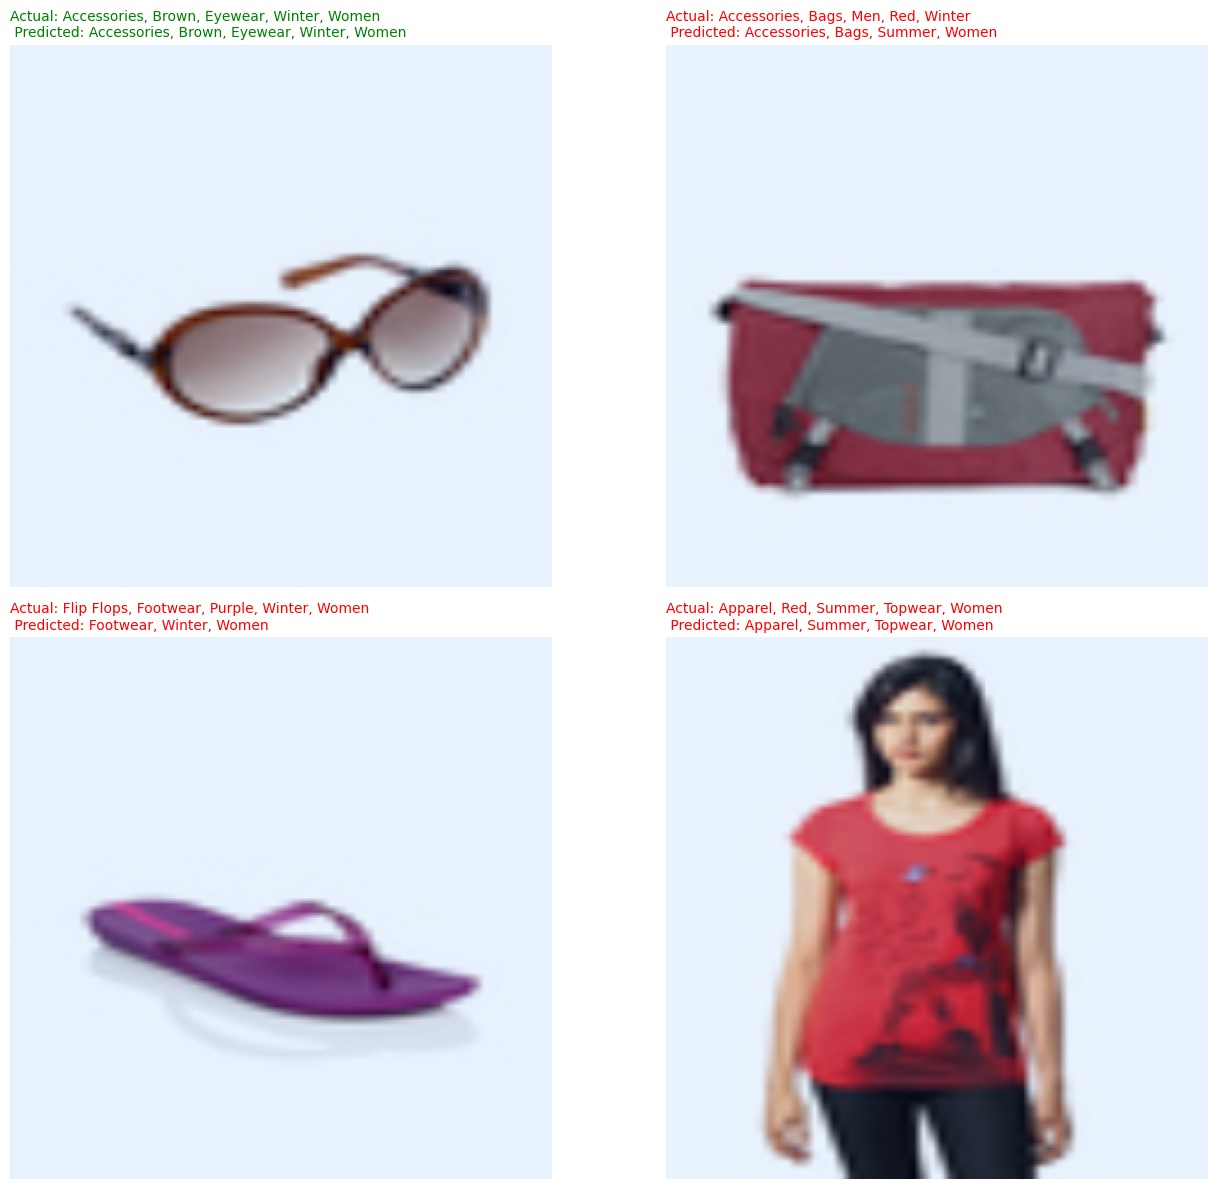

In [35]:
import matplotlib.pyplot as plt
import random

def predict_and_show_samples(model, dataset, idx_to_tag, device, num_samples=4, threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    indices = random.sample(range(len(dataset)), num_samples)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            # 1. 데이터셋에서 이미지와 정답 가져오기
            image, target = dataset[idx]

            # 2. 모델 예측 (배치 차원 추가 후 GPU 이송)
            inputs = image.unsqueeze(0).to(device)
            outputs = model(inputs)

            # 3. Sigmoid를 통과시켜 확률값으로 변환
            probs = torch.sigmoid(outputs).cpu().numpy()[0]

            # 4. 설정한 임계값(Threshold)보다 높으면 1(True), 낮으면 0(False)으로 이진화
            preds_bin = (probs >= threshold).astype(int)

            # 5. 인덱스를 다시 인간이 읽을 수 있는 문자열 태그로 디코딩
            actual_tags = [idx_to_tag[j] for j, val in enumerate(target) if val == 1]
            pred_tags = [idx_to_tag[j] for j, val in enumerate(preds_bin) if val == 1]

            # 6. 시각화를 위해 이미지 텐서를 원본 이미지 형태로 역전환 (H, W, C)
            # Albumentations 전처리로 인해 변형된 채널을 복구합니다.
            img_display = image.permute(1, 2, 0).numpy()
            # 정규화(Normalization) 풀기 (가시성을 위해 0~1로 클리핑)
            img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)

            # 7. 그리드에 이미지 및 텍스트 렌더링
            axes[i].imshow(img_display)
            axes[i].axis('off')

            # 정답과 예측값을 가독성 좋게 줄바꿈 처리
            title_text = f"Actual: {', '.join(actual_tags)}\n Predicted: {', '.join(pred_tags)}"

            # 전부 다 맞히면 초록색 글씨, 하나라도 틀리면 빨간색 글씨
            is_correct = set(actual_tags) == set(pred_tags)
            title_color = 'green' if is_correct else 'red'

            axes[i].set_title(title_text, fontsize=10, loc='left', color=title_color)

    plt.tight_layout()
    plt.show()

# 시각화 가동
predict_and_show_samples(model, val_dataset, idx_to_tag, device, num_samples=4, threshold=0.5)